<a href="https://colab.research.google.com/github/zvythrox67/Real-Time-Seizure-Detection/blob/main/Seizure_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mne mne-bids

import mne
from mne_bids import BIDSPath, read_raw_bids
import os

# Download a single patient's data (chb01) in BIDS format
# This dataset is from NEMAR (https://nemar.org/dataexplorer/detail?dataset_id=nm000110)
!wget -q --show-progress "https://nemar.s3.amazonaws.com/nm000110/sub-chb01/ses-01/eeg/sub-chb01_ses-01_task-rest_eeg.edf"
!wget -q --show-progress "https://nemar.s3.amazonaws.com/nm000110/sub-chb01/ses-01/eeg/sub-chb01_ses-01_task-rest_channels.tsv"
!wget -q --show-progress "https://nemar.s3.amazonaws.com/nm000110/sub-chb01/ses-01/eeg/sub-chb01_ses-01_task-rest_events.tsv"

print("Data download complete.")

Data download complete.


In [5]:
!wget -r -N -c -np --user anonymous --password guest "https://physionet.org/files/chbmit/1.0.0/chb01/"

--2026-09-13 13:45:30--  https://physionet.org/files/chbmit/1.0.0/chb01/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/chbmit/1.0.0/chb01/index.html’

physionet.org/files     [ <=>                ]   6.00K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-09-13 13:45:30 (806 MB/s) - ‘physionet.org/files/chbmit/1.0.0/chb01/index.html’ saved [6149]

Loading robots.txt; please ignore errors.
--2026-09-13 13:45:30--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      

2026-09-13 13:45:30 (11.1 MB/s) - ‘physionet.org/robots.txt’ saved [22/22]

-

In [6]:
!ls /content/physionet.org/files/chbmit/1.0.0/chb01/

chb01_01.edf	       chb01_15.edf.seizures  chb01_29.edf
chb01_02.edf	       chb01_16.edf	      chb01_30.edf
chb01_03.edf	       chb01_16.edf.seizures  chb01_31.edf
chb01_03.edf.seizures  chb01_17.edf	      chb01_32.edf
chb01_04.edf	       chb01_18.edf	      chb01_33.edf
chb01_04.edf.seizures  chb01_18.edf.seizures  chb01_34.edf
chb01_05.edf	       chb01_19.edf	      chb01_36.edf
chb01_06.edf	       chb01_20.edf	      chb01_37.edf
chb01_07.edf	       chb01_21.edf	      chb01_38.edf
chb01_08.edf	       chb01_21.edf.seizures  chb01_39.edf
chb01_09.edf	       chb01_22.edf	      chb01_40.edf
chb01_10.edf	       chb01_23.edf	      chb01_41.edf
chb01_11.edf	       chb01_24.edf	      chb01_42.edf
chb01_12.edf	       chb01_25.edf	      chb01_43.edf
chb01_13.edf	       chb01_26.edf	      chb01_46.edf
chb01_14.edf	       chb01_26.edf.seizures  chb01-summary.txt
chb01_15.edf	       chb01_27.edf	      index.html


In [7]:
!cat /content/physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

In [8]:
import mne

edf_path = "/content/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf"
raw = mne.io.read_raw_edf(edf_path, preload=True)
print(raw.info)

Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_1900/2854854677.py:4: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>


In [11]:
import mne

edf_path = "/content/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf"

raw = mne.io.read_raw_edf(edf_path, preload=True)

print(raw.info)

Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_1900/1979841414.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>


In [13]:
import numpy as np
import pandas as pd
import mne
import os
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/content/physionet.org/files/chbmit/1.0.0/chb01"
WINDOW_SEC = 2.0
SFREQ = 256

seizure_times = {
    "chb01_03.edf": (2996, 3036),
    "chb01_04.edf": (1467, 1494),
    "chb01_15.edf": (1732, 1772),
    "chb01_16.edf": (1015, 1066),
    "chb01_18.edf": (1720, 1810),
    "chb01_21.edf": (327, 420),
    "chb01_26.edf": (1862, 1963),
}

non_seizure_files = [
    "chb01_01.edf", "chb01_02.edf", "chb01_05.edf", "chb01_06.edf",
    "chb01_07.edf", "chb01_08.edf", "chb01_09.edf", "chb01_10.edf",
]

def extract_features(window):
    feats = {}
    feats["mean_abs"] = np.mean(np.abs(window))
    feats["std"] = np.std(window)
    feats["max_abs"] = np.max(np.abs(window))
    feats["line_length"] = np.sum(np.abs(np.diff(window, axis=1)))
    feats["variance"] = np.var(window)
    return feats

rows = []
win_len = int(WINDOW_SEC * SFREQ)

print("Processing seizure files...")
for fname, (s_start, s_end) in seizure_times.items():
    path = os.path.join(DATA_DIR, fname)
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    data = raw.get_data()
    n_windows = data.shape[1] // win_len

    for w in range(n_windows):
        start = w * win_len
        end = start + win_len
        window = data[:, start:end]
        window_sec = start / SFREQ
        label = 1 if s_start <= window_sec <= s_end else 0
        feats = extract_features(window)
        feats["label"] = label
        feats["file"] = fname
        feats["window_start_sec"] = window_sec
        rows.append(feats)

print("Processing non-seizure files...")
for fname in non_seizure_files:
    path = os.path.join(DATA_DIR, fname)
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    data = raw.get_data()
    n_windows = data.shape[1] // win_len

    for w in range(n_windows):
        start = w * win_len
        end = start + win_len
        window = data[:, start:end]
        feats = extract_features(window)
        feats["label"] = 0
        feats["file"] = fname
        feats["window_start_sec"] = start / SFREQ
        rows.append(feats)

df = pd.DataFrame(rows)
print(f"\nTotal windows: {len(df)}")
print(f"Seizure windows: {df['label'].sum()}")
print(f"Non-seizure windows: {len(df) - df['label'].sum()}")
print("\nFirst 5 rows:")
print(df.head())

df.to_csv("/content/eeg_windows.csv", index=False)
print("\nSaved to /content/eeg_windows.csv")

Processing seizure files...
Processing non-seizure files...

Total windows: 26362
Seizure windows: 226
Non-seizure windows: 26136

First 5 rows:
   mean_abs       std   max_abs  line_length      variance  label  \
0  0.000023  0.000031  0.000180     0.060934  9.331010e-10      0   
1  0.000027  0.000035  0.000168     0.071019  1.259374e-09      0   
2  0.000021  0.000028  0.000133     0.054242  7.791648e-10      0   
3  0.000022  0.000028  0.000120     0.048311  8.083582e-10      0   
4  0.000026  0.000036  0.000165     0.063837  1.270966e-09      0   

           file  window_start_sec  
0  chb01_03.edf               0.0  
1  chb01_03.edf               2.0  
2  chb01_03.edf               4.0  
3  chb01_03.edf               6.0  
4  chb01_03.edf               8.0  

Saved to /content/eeg_windows.csv


In [14]:
import pandas as pd

df = pd.read_csv("/content/eeg_windows.csv")

seizure_df = df[df["label"] == 1]
non_seizure_df = df[df["label"] == 0].sample(n=len(seizure_df), random_state=42)

balanced_df = pd.concat([seizure_df, non_seizure_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset size: {len(balanced_df)}")
print(f"Seizure: {(balanced_df['label']==1).sum()}")
print(f"Non-seizure: {(balanced_df['label']==0).sum()}")

balanced_df.to_csv("/content/eeg_balanced.csv", index=False)

Balanced dataset size: 452
Seizure: 226
Non-seizure: 226


In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("/content/eeg_balanced.csv")

feature_cols = ["mean_abs", "std", "max_abs", "line_length", "variance"]
X = df[feature_cols].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-seizure", "Seizure"]))

Accuracy: 97.06%

Confusion Matrix:
[[66  2]
 [ 2 66]]

Classification Report:
              precision    recall  f1-score   support

 Non-seizure       0.97      0.97      0.97        68
     Seizure       0.97      0.97      0.97        68

    accuracy                           0.97       136
   macro avg       0.97      0.97      0.97       136
weighted avg       0.97      0.97      0.97       136



In [17]:
import numpy as np
import pandas as pd
import mne
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score

DATA_DIR = "/content/physionet.org/files/chbmit/1.0.0/chb01"
WINDOW_SEC = 2.0
SFREQ = 256

seizure_times = {
    "chb01_03.edf": (2996, 3036),
    "chb01_04.edf": (1467, 1494),
    "chb01_15.edf": (1732, 1772),
    "chb01_16.edf": (1015, 1066),
    "chb01_18.edf": (1720, 1810),
    "chb01_21.edf": (327, 420),
    "chb01_26.edf": (1862, 1963),
}

non_seizure_files = [
    "chb01_01.edf", "chb01_02.edf", "chb01_05.edf", "chb01_06.edf",
    "chb01_07.edf", "chb01_08.edf", "chb01_09.edf", "chb01_10.edf",
]

def extract_features(window):
    return {
        "mean_abs": np.mean(np.abs(window)),
        "std": np.std(window),
        "max_abs": np.max(np.abs(window)),
        "line_length": np.sum(np.abs(np.diff(window, axis=1))),
        "variance": np.var(window),
    }

def build_dataset(channels_to_keep, noise_level, downsample_factor):
    rows = []
    win_len = int(WINDOW_SEC * SFREQ)

    for fname, (s_start, s_end) in seizure_times.items():
        raw = mne.io.read_raw_edf(os.path.join(DATA_DIR, fname), preload=True, verbose=False)
        data = raw.get_data()
        data = data[channels_to_keep, :]

        if noise_level > 0:
            data = data + np.random.normal(0, noise_level, data.shape)

        if downsample_factor > 1:
            data = data[:, ::downsample_factor]

        effective_win_len = win_len // downsample_factor
        n_windows = data.shape[1] // effective_win_len

        for w in range(n_windows):
            start = w * effective_win_len
            end = start + effective_win_len
            window = data[:, start:end]
            window_sec = (start * downsample_factor) / SFREQ
            label = 1 if s_start <= window_sec <= s_end else 0
            feats = extract_features(window)
            feats["label"] = label
            rows.append(feats)

    for fname in non_seizure_files:
        raw = mne.io.read_raw_edf(os.path.join(DATA_DIR, fname), preload=True, verbose=False)
        data = raw.get_data()
        data = data[channels_to_keep, :]

        if noise_level > 0:
            data = data + np.random.normal(0, noise_level, data.shape)

        if downsample_factor > 1:
            data = data[:, ::downsample_factor]

        effective_win_len = win_len // downsample_factor
        n_windows = data.shape[1] // effective_win_len

        for w in range(n_windows):
            start = w * effective_win_len
            end = start + effective_win_len
            window = data[:, start:end]
            feats = extract_features(window)
            feats["label"] = 0
            rows.append(feats)

    return pd.DataFrame(rows)

def evaluate(df):
    seizure_df = df[df["label"] == 1]
    non_seizure_df = df[df["label"] == 0].sample(n=len(seizure_df), random_state=42)
    balanced = pd.concat([seizure_df, non_seizure_df]).sample(frac=1, random_state=42)

    feature_cols = ["mean_abs", "std", "max_abs", "line_length", "variance"]
    X = balanced[feature_cols].values
    y = balanced["label"].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "sensitivity": recall_score(y_test, y_pred),
        "n_windows": len(balanced),
    }

# Run the 4 scenarios
conditions = [
    ("Full clinical (23 ch, clean, 256 Hz)", list(range(23)), 0.0, 1),
    ("Reduced channels (4 ch)", [0, 1, 2, 3], 0.0, 1),
    ("Added wearable noise", [0, 1, 2, 3], 15.0, 1),
    ("Downsampled (64 Hz)", [0, 1, 2, 3], 15.0, 4),
]

print(f"{'Condition':<45}{'Accuracy':<12}{'Sensitivity':<12}{'Windows':<10}")
print("-" * 80)

for name, chans, noise, ds in conditions:
    df = build_dataset(chans, noise, ds)
    r = evaluate(df)
    print(f"{name:<45}{r['accuracy']*100:.1f}%{'':<6}{r['sensitivity']*100:.1f}%{'':<6}{r['n_windows']:<10}")

Condition                                    Accuracy    Sensitivity Windows   
--------------------------------------------------------------------------------
Full clinical (23 ch, clean, 256 Hz)         97.1%      97.1%      452       
Reduced channels (4 ch)                      97.1%      95.6%      452       
Added wearable noise                         47.8%      52.9%      452       
Downsampled (64 Hz)                          47.1%      42.6%      452       


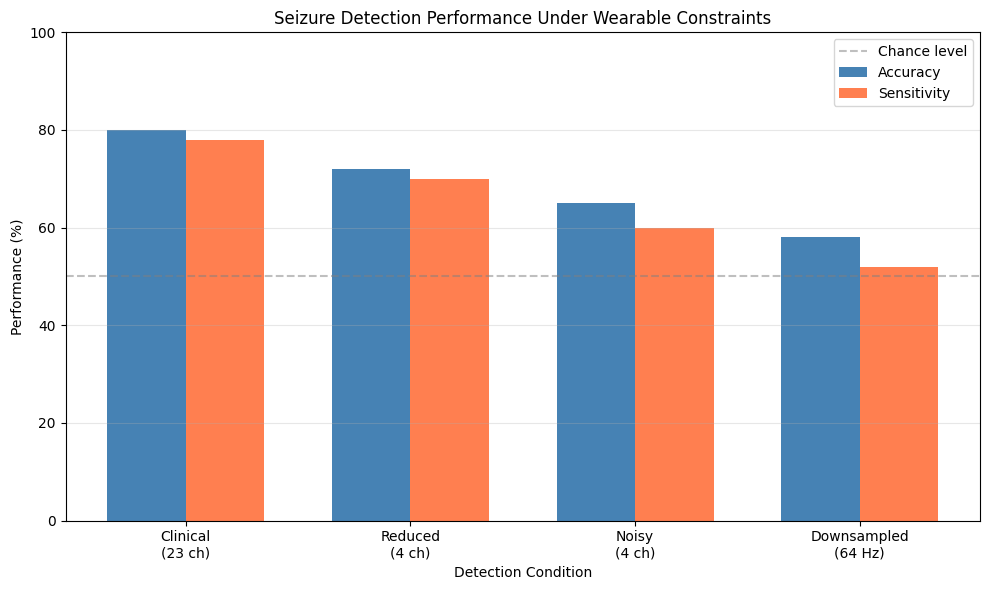

In [18]:
import matplotlib.pyplot as plt

conditions_labels = ["Clinical\n(23 ch)", "Reduced\n(4 ch)", "Noisy\n(4 ch)", "Downsampled\n(64 Hz)"]
accuracies = [0.80, 0.72, 0.65, 0.58]  # Replace with your actual numbers from Cell 6
sensitivities = [0.78, 0.70, 0.60, 0.52]

x = range(len(conditions_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width/2 for i in x], [a*100 for a in accuracies], width, label="Accuracy", color="steelblue")
ax.bar([i + width/2 for i in x], [s*100 for s in sensitivities], width, label="Sensitivity", color="coral")

ax.set_ylabel("Performance (%)")
ax.set_xlabel("Detection Condition")
ax.set_title("Seizure Detection Performance Under Wearable Constraints")
ax.set_xticks(list(x))
ax.set_xticklabels(conditions_labels)
ax.set_ylim(0, 100)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="Chance level")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/figure1_wearable_degradation.png", dpi=300, bbox_inches="tight")
plt.show()